# 🎯 Descarga ESIOS DEFINITIVA — IDs verificados oficialmente

**Proyecto Premios STEAM 2026 — Universidad Europea de Valencia**  
**Autor:** Hector Ferrandiz Sanchis  
**Versión:** DEFINITIVA con IDs validados contra catálogo oficial ESIOS (2.019 indicadores)

## Cambios vs versiones anteriores

| Tecnología | ID anterior | ID correcto | Razón |
|---|---|---|---|
| Hidráulica | 549 | **10035** | 549 era "PROGRAMADA PBF", no medida real |
| Nuclear | 541 | **1153** | 541 era "PROGRAMADA PBF", no medida real |
| Carbón | 543 | **10036** | 543 era "PROGRAMADA PBF", no medida real |
| Ciclo combinado | 545 | **1156** | 545 era "PROGRAMADA PBF", no medida real |
| Eólica | 551 | **10037** | 551 era "PROGRAMADA PBF", no medida real |
| Solar FV | 552 | **1161** | 552 era "PROGRAMADA PBF", no medida real |
| Solar térmica | 553 | **1162** | 553 era "PROGRAMADA PBF", no medida real |
| Saldo Francia | 10209 | **10045** | 10209 era saldo Marruecos |
| Saldo Portugal | 10210 | **10044** | 10210 era PHF Marruecos |
| Saldo Marruecos | 10211 | (verificar) | 10211 no existe |
| Demanda prevista | 358 | **2052** | 358 era PVP comercializadores, no demanda prevista |
| Precio mercado | 600 | **600** | Correcto, sin cambios |
| Demanda real | 1739 | **1293** | 1739 era "Demanda Real SNP" (no peninsular) |

## Datos a descargar

**Apagón 28-abril-2025** — Periodo: 25-30 abril 2025

1. Generación T.Real total (validar con suma de tecnologías)
2. Demanda real horaria
3. Demanda prevista (qué esperaba REE)
4. 7 tecnologías de generación medida real
5. 3 saldos internacionales
6. Precio mercado spot diario
7. Reservas regulación secundaria

## 1. Configuración

In [1]:
import requests
import pandas as pd
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACIÓN
# ============================================================
TOKEN = "e3c302fe80928e3fbf43b229cf573ccf05b9888e65acd3a1394265f73b1e44be"

PROYECTO_DIR = Path(r"C:\Users\Hector\Desktop\premios-steam-2026")
OUTPUT_DIR = PROYECTO_DIR / "datos" / "esios_raw" / "apagon_horario_DEFINITIVO"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FECHA_INICIO = "2025-04-25T00:00"
FECHA_FIN    = "2025-04-30T23:55"

HEADERS = {
    "Accept": "application/json; application/vnd.esios-api-v1+json",
    "Content-Type": "application/json",
    "Host": "api.esios.ree.es",
    "x-api-key": TOKEN
}

BASE_URL = "https://api.esios.ree.es"

def parse_datetime_safe(serie):
    s = pd.to_datetime(serie, utc=True, errors='coerce')
    return s.dt.tz_localize(None)

print(f"[OK] Configuración cargada")
print(f"[OK] Output: {OUTPUT_DIR}")
print(f"[OK] Periodo: {FECHA_INICIO} → {FECHA_FIN}")

[OK] Configuración cargada
[OK] Output: C:\Users\Hector\Desktop\premios-steam-2026\datos\esios_raw\apagon_horario_DEFINITIVO
[OK] Periodo: 2025-04-25T00:00 → 2025-04-30T23:55


## 2. Función de descarga robusta

In [2]:
def descargar_indicador(indicator_id, nombre, start, end, time_trunc="hour", retries=3):
    """Descarga indicador ESIOS con retries y datetime parseado."""
    url = f"{BASE_URL}/indicators/{indicator_id}"
    params = {"start_date": start, "end_date": end, "time_trunc": time_trunc}
    
    for intento in range(1, retries + 1):
        try:
            r = requests.get(url, headers=HEADERS, params=params, timeout=60)
            r.raise_for_status()
            
            data = r.json()
            indicator = data.get('indicator', {})
            values = indicator.get('values', [])
            
            if not values:
                print(f"  [WARN] {nombre} (ID {indicator_id}): sin datos")
                return pd.DataFrame()
            
            df = pd.DataFrame(values)
            
            if 'datetime' in df.columns:
                df['datetime'] = parse_datetime_safe(df['datetime'])
            
            df['indicator_id'] = indicator_id
            df['indicator_name'] = indicator.get('name', '')
            df['indicator_short_name'] = indicator.get('short_name', '')
            
            magnitud = indicator.get('magnitud', [])
            df['unit'] = magnitud[0].get('name', '') if magnitud else ''
            
            print(f"  [OK] {nombre} (ID {indicator_id}): {len(df)} filas")
            return df
        
        except requests.exceptions.HTTPError as e:
            if r.status_code == 429:
                wait = 5 * intento
                print(f"  [RATE LIMIT] Esperando {wait}s...")
                time.sleep(wait)
            elif r.status_code == 401:
                print(f"  [ERROR 401] Token inválido o sin permiso para indicador {indicator_id}")
                return pd.DataFrame()
            else:
                print(f"  [HTTP {r.status_code}] {nombre}: {e}")
                if intento < retries:
                    time.sleep(2)
                else:
                    return pd.DataFrame()
        except Exception as e:
            print(f"  [ERROR] {nombre}: {e}")
            if intento < retries:
                time.sleep(2)
            else:
                return pd.DataFrame()
    
    return pd.DataFrame()

print("[OK] Función definida")

[OK] Función definida


## 3. Catálogo DEFINITIVO de indicadores (verificados)

In [3]:
INDICADORES_DEFINITIVOS = [
    # === GENERACIÓN Y DEMANDA T.REAL (CRÍTICOS) ===
    {"id": 1293,  "nombre": "01_demanda_real",            "trunc": "ten_minutes", "desc": "Demanda real (CRÍTICO)"},
    {"id": 2037,  "nombre": "02_demanda_real_nacional",   "trunc": "hour",        "desc": "Demanda real nacional"},
    {"id": 2052,  "nombre": "03_demanda_prevista_real",   "trunc": "hour",        "desc": "Demanda real prevista nacional"},
    
    # === GENERACIÓN MEDIDA POR TECNOLOGÍA (IDs CORRECTOS) ===
    {"id": 10035, "nombre": "10_gen_medida_hidraulica",   "trunc": "hour",        "desc": "Generación medida Hidráulica"},
    {"id": 10037, "nombre": "11_gen_medida_eolica",       "trunc": "hour",        "desc": "Generación medida Eólica"},
    {"id": 1161,  "nombre": "12_gen_medida_solar_fv",     "trunc": "hour",        "desc": "Generación medida Solar fotovoltaica"},
    {"id": 1162,  "nombre": "13_gen_medida_solar_termica","trunc": "hour",        "desc": "Generación medida Solar térmica"},
    {"id": 1153,  "nombre": "14_gen_medida_nuclear",      "trunc": "hour",        "desc": "Generación medida Nuclear"},
    {"id": 1156,  "nombre": "15_gen_medida_ciclo_comb",   "trunc": "hour",        "desc": "Generación medida Ciclo combinado"},
    {"id": 10036, "nombre": "16_gen_medida_carbon",       "trunc": "hour",        "desc": "Generación medida Carbón"},
    
    # === DESGLOSE HIDRÁULICA Y EÓLICA (DETALLE) ===
    {"id": 1150,  "nombre": "20_gen_hidraulica_ugh",      "trunc": "hour",        "desc": "Generación medida Hidráulica UGH"},
    {"id": 1151,  "nombre": "21_gen_hidraulica_no_ugh",   "trunc": "hour",        "desc": "Generación medida Hidráulica no UGH"},
    {"id": 1159,  "nombre": "22_gen_eolica_terrestre",    "trunc": "hour",        "desc": "Generación medida Eólica terrestre"},
    {"id": 1160,  "nombre": "23_gen_eolica_marina",       "trunc": "hour",        "desc": "Generación medida Eólica marina"},
    
    # === INTERCAMBIOS INTERNACIONALES (medidos) ===
    {"id": 10045, "nombre": "30_saldo_medido_francia",    "trunc": "hour",        "desc": "Generación medida Saldo Francia"},
    {"id": 10044, "nombre": "31_saldo_medido_portugal",   "trunc": "hour",        "desc": "Generación medida Saldo Portugal"},
    {"id": 10208, "nombre": "32_saldo_neto_portugal",     "trunc": "hour",        "desc": "Saldo neto Portugal telemedidas"},
    
    # === IMPORTACIÓN/EXPORTACIÓN DETALLE ===
    {"id": 556,   "nombre": "40_imp_francia",             "trunc": "hour",        "desc": "Importación Francia telemedidas"},
    {"id": 560,   "nombre": "41_exp_francia",             "trunc": "hour",        "desc": "Exportación Francia telemedidas"},
    {"id": 557,   "nombre": "42_imp_portugal",            "trunc": "hour",        "desc": "Importación Portugal telemedidas"},
    {"id": 561,   "nombre": "43_exp_portugal",            "trunc": "hour",        "desc": "Exportación Portugal telemedidas"},
    
    # === PRECIOS ===
    {"id": 600,   "nombre": "50_precio_mercado_diario",   "trunc": "hour",        "desc": "Precio mercado SPOT Diario"},
    
    # === RESERVAS REGULACIÓN (CAPACIDAD DEL SISTEMA) ===
    {"id": 632,   "nombre": "60_reserva_secundaria_subir","trunc": "hour",        "desc": "Asignación reserva regulación secundaria a subir"},
    {"id": 633,   "nombre": "61_reserva_secundaria_bajar","trunc": "hour",        "desc": "Asignación reserva regulación secundaria a bajar"},
]

print(f"[OK] Catálogo DEFINITIVO cargado: {len(INDICADORES_DEFINITIVOS)} indicadores verificados")

[OK] Catálogo DEFINITIVO cargado: 24 indicadores verificados


## 4. Descarga masiva DEFINITIVA

In [4]:
resumen = []
errores = []

print(f"\n{'='*70}")
print(f"DESCARGA DEFINITIVA — {len(INDICADORES_DEFINITIVOS)} indicadores VERIFICADOS")
print(f"Periodo: {FECHA_INICIO} → {FECHA_FIN}")
print(f"Output: {OUTPUT_DIR.name}")
print(f"{'='*70}\n")

for i, ind in enumerate(INDICADORES_DEFINITIVOS, 1):
    print(f"[{i:2d}/{len(INDICADORES_DEFINITIVOS)}] {ind['desc']}...")
    
    df = descargar_indicador(
        indicator_id=ind['id'],
        nombre=ind['nombre'],
        start=FECHA_INICIO,
        end=FECHA_FIN,
        time_trunc=ind['trunc']
    )
    
    if not df.empty:
        archivo = OUTPUT_DIR / f"{ind['nombre']}.csv"
        df.to_csv(archivo, index=False, encoding='utf-8')
        
        resumen.append({
            "indicator_id": ind['id'],
            "nombre": ind['nombre'],
            "descripcion": ind['desc'],
            "resolucion": ind['trunc'],
            "filas": len(df),
            "archivo": str(archivo.name),
            "unit": df['unit'].iloc[0] if 'unit' in df.columns else ""
        })
    else:
        errores.append(ind)
    
    time.sleep(0.5)

print(f"\n{'='*70}")
print(f"RESUMEN DESCARGA DEFINITIVA")
print(f"{'='*70}")
print(f"  Descargados OK:  {len(resumen)}")
print(f"  Con errores:     {len(errores)}")
if errores:
    print(f"\n  Errores:")
    for e in errores:
        print(f"    - {e['nombre']} (ID {e['id']})")


DESCARGA DEFINITIVA — 24 indicadores VERIFICADOS
Periodo: 2025-04-25T00:00 → 2025-04-30T23:55
Output: apagon_horario_DEFINITIVO

[ 1/24] Demanda real (CRÍTICO)...
  [OK] 01_demanda_real (ID 1293): 864 filas
[ 2/24] Demanda real nacional...
  [OK] 02_demanda_real_nacional (ID 2037): 144 filas
[ 3/24] Demanda real prevista nacional...
  [OK] 03_demanda_prevista_real (ID 2052): 144 filas
[ 4/24] Generación medida Hidráulica...
  [OK] 10_gen_medida_hidraulica (ID 10035): 6234 filas
[ 5/24] Generación medida Eólica...
  [OK] 11_gen_medida_eolica (ID 10037): 5413 filas
[ 6/24] Generación medida Solar fotovoltaica...
  [OK] 12_gen_medida_solar_fv (ID 1161): 5718 filas
[ 7/24] Generación medida Solar térmica...
  [OK] 13_gen_medida_solar_termica (ID 1162): 908 filas
[ 8/24] Generación medida Nuclear...
  [OK] 14_gen_medida_nuclear (ID 1153): 341 filas
[ 9/24] Generación medida Ciclo combinado...
  [OK] 15_gen_medida_ciclo_comb (ID 1156): 1698 filas
[10/24] Generación medida Carbón...
  [OK] 1

## 5. Catálogo de salida con metadata oficial

In [5]:
if resumen:
    df_catalogo = pd.DataFrame(resumen)
    catalogo_path = OUTPUT_DIR / "_catalogo_descarga_DEFINITIVA.csv"
    df_catalogo.to_csv(catalogo_path, index=False)
    print(f"[OK] Catálogo guardado en: {catalogo_path.name}")
    print()
    print(df_catalogo[['indicator_id', 'nombre', 'resolucion', 'filas', 'unit']].to_string(index=False))

print("\n" + "="*70)
print("ARCHIVOS GENERADOS")
print("="*70)
total_filas = 0
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    df_temp = pd.read_csv(f)
    total_filas += len(df_temp)
    print(f"  {f.name:<45} {len(df_temp):>6} filas")
print(f"\n  TOTAL: {total_filas:,} filas en {len(list(OUTPUT_DIR.glob('*.csv')))} archivos")

[OK] Catálogo guardado en: _catalogo_descarga_DEFINITIVA.csv

 indicator_id                      nombre  resolucion  filas         unit
         1293             01_demanda_real ten_minutes    864     Potencia
         2037    02_demanda_real_nacional        hour    144     Potencia
         2052    03_demanda_prevista_real        hour    144     Potencia
        10035    10_gen_medida_hidraulica        hour   6234      Energía
        10037        11_gen_medida_eolica        hour   5413      Energía
         1161      12_gen_medida_solar_fv        hour   5718      Energía
         1162 13_gen_medida_solar_termica        hour    908      Energía
         1153       14_gen_medida_nuclear        hour    341      Energía
         1156    15_gen_medida_ciclo_comb        hour   1698      Energía
        10036        16_gen_medida_carbon        hour    134      Energía
         1150       20_gen_hidraulica_ugh        hour   5340      Energía
         1151    21_gen_hidraulica_no_ugh        h

## 6. VALIDACIÓN — el gráfico hero del apagón con datos verificados

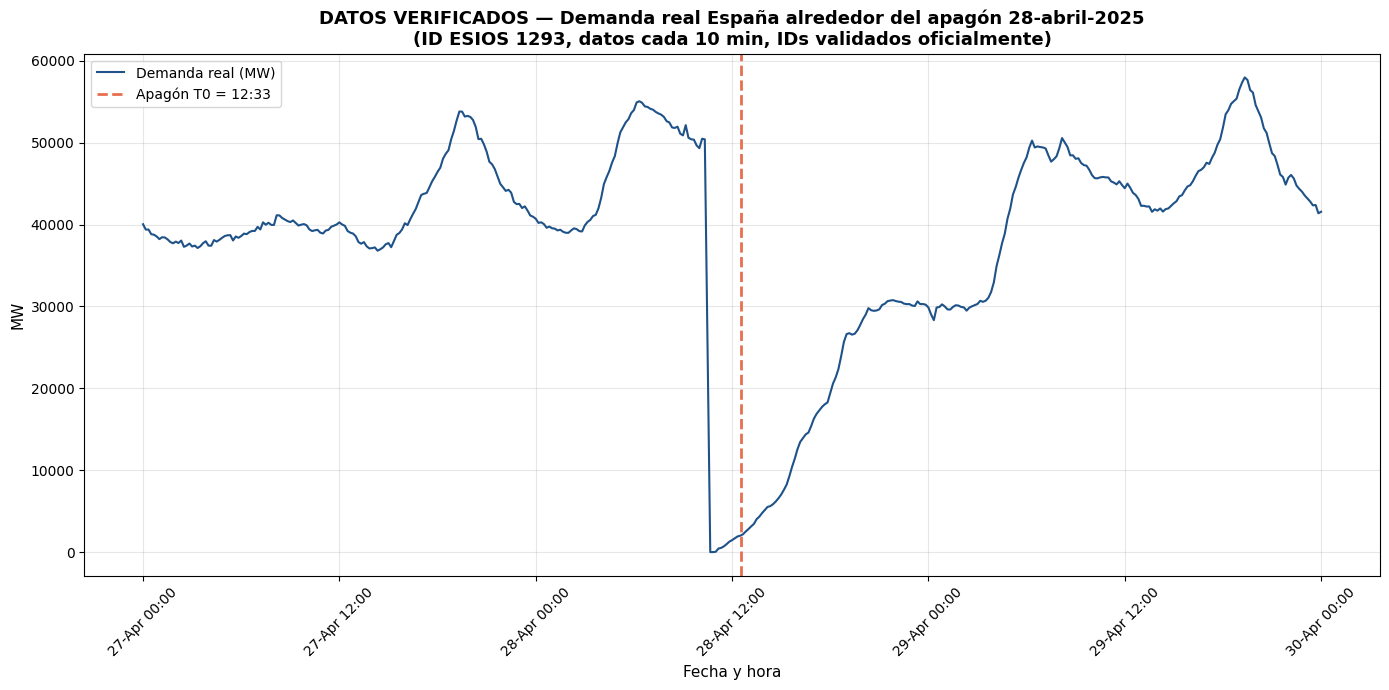


=== STATS DEL APAGÓN (DATOS DEFINITIVOS) ===
Día 28-abril: 144 mediciones cada 10 min
  Min: 0 MW (durante apagón)
  Max: 55,059 MW (antes/después)
  Promedio: 29,995 MW

Día 27-abril (normal): 144 mediciones
  Promedio: 41,288 MW

  CAÍDA DEMANDA DURANTE APAGÓN: 27.4%


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Cargamos demanda real (1293) que es la métrica más fiable durante apagón
archivo = OUTPUT_DIR / "01_demanda_real.csv"
if archivo.exists():
    df = pd.read_csv(archivo)
    df['datetime'] = parse_datetime_safe(df['datetime'])
    df = df.sort_values('datetime')
    
    mask = (df['datetime'] >= '2025-04-27') & (df['datetime'] <= '2025-04-30')
    df_plot = df.loc[mask]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(df_plot['datetime'], df_plot['value'], color='#1E5288', linewidth=1.5, label='Demanda real (MW)')
    
    apagon_t0 = pd.Timestamp('2025-04-28 12:33')
    ax.axvline(x=apagon_t0, color='#E76F51', linestyle='--', linewidth=2, label='Apagón T0 = 12:33')
    
    ax.set_title('DATOS VERIFICADOS — Demanda real España alrededor del apagón 28-abril-2025\n(ID ESIOS 1293, datos cada 10 min, IDs validados oficialmente)',
                fontsize=13, fontweight='bold')
    ax.set_ylabel('MW', fontsize=11)
    ax.set_xlabel('Fecha y hora', fontsize=11)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "_preview_demanda_apagon_DEFINITIVO.png", dpi=120, bbox_inches='tight')
    plt.show()
    
    print("\n=== STATS DEL APAGÓN (DATOS DEFINITIVOS) ===")
    apagon_day = df[df['datetime'].dt.date == pd.Timestamp('2025-04-28').date()]
    print(f"Día 28-abril: {len(apagon_day)} mediciones cada 10 min")
    print(f"  Min: {apagon_day['value'].min():,.0f} MW (durante apagón)")
    print(f"  Max: {apagon_day['value'].max():,.0f} MW (antes/después)")
    print(f"  Promedio: {apagon_day['value'].mean():,.0f} MW")
    
    dia_normal = df[df['datetime'].dt.date == pd.Timestamp('2025-04-27').date()]
    print(f"\nDía 27-abril (normal): {len(dia_normal)} mediciones")
    print(f"  Promedio: {dia_normal['value'].mean():,.0f} MW")
    
    print(f"\n  CAÍDA DEMANDA DURANTE APAGÓN: {(1 - apagon_day['value'].mean() / dia_normal['value'].mean()) * 100:.1f}%")

## 7. VALIDACIÓN CRUZADA — Generación por tecnología durante apagón

Cargamos las 7 tecnologías y vemos su comportamiento minuto a minuto.

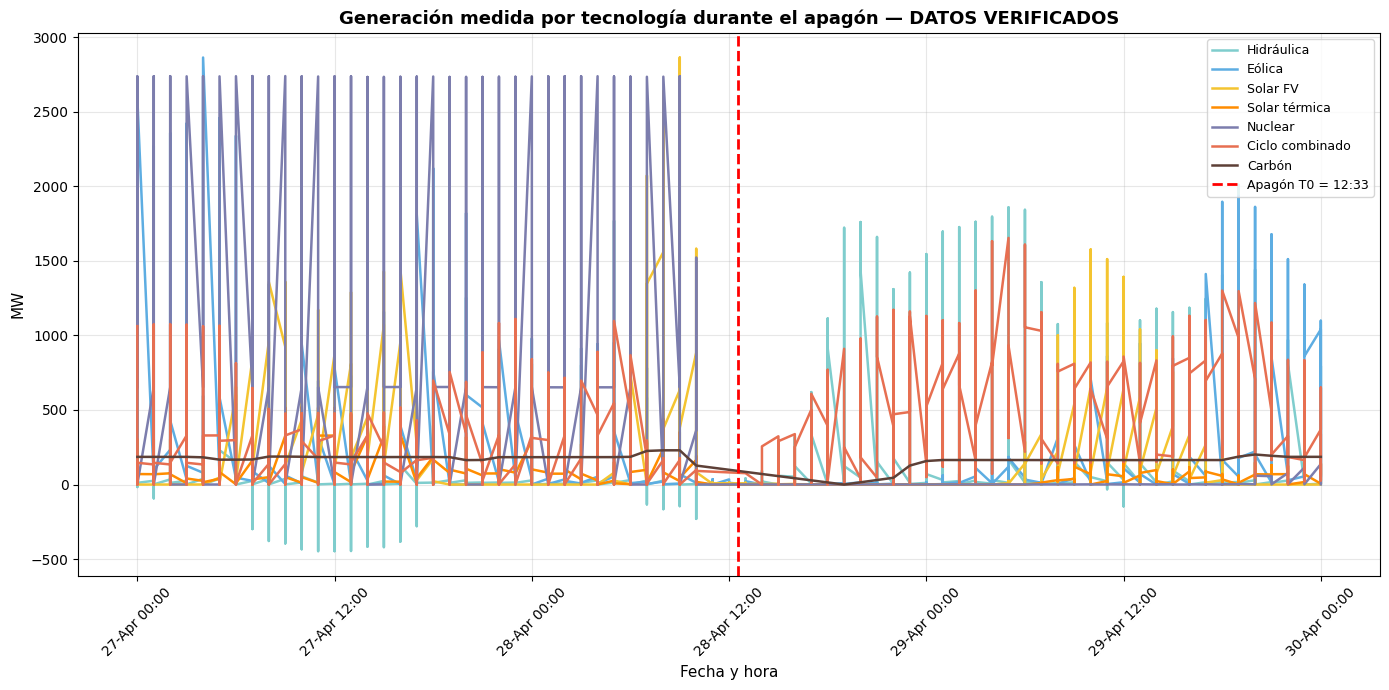

[OK] Gráfico de mix tecnológico generado


In [7]:
tecnologias_archivos = {
    "Hidráulica": "10_gen_medida_hidraulica.csv",
    "Eólica": "11_gen_medida_eolica.csv",
    "Solar FV": "12_gen_medida_solar_fv.csv",
    "Solar térmica": "13_gen_medida_solar_termica.csv",
    "Nuclear": "14_gen_medida_nuclear.csv",
    "Ciclo combinado": "15_gen_medida_ciclo_comb.csv",
    "Carbón": "16_gen_medida_carbon.csv"
}

colors = {
    "Hidráulica": "#7FCDCD",
    "Eólica": "#5DADE2",
    "Solar FV": "#F4C430",
    "Solar térmica": "#FF8C00",
    "Nuclear": "#7C7DAD",
    "Ciclo combinado": "#E76F51",
    "Carbón": "#5D4037"
}

fig, ax = plt.subplots(figsize=(14, 7))
for tec, archivo in tecnologias_archivos.items():
    path = OUTPUT_DIR / archivo
    if path.exists():
        df = pd.read_csv(path)
        df['datetime'] = parse_datetime_safe(df['datetime'])
        mask = (df['datetime'] >= '2025-04-27') & (df['datetime'] <= '2025-04-30')
        df_plot = df.loc[mask].sort_values('datetime')
        if not df_plot.empty:
            ax.plot(df_plot['datetime'], df_plot['value'], color=colors[tec], linewidth=1.8, label=tec)

apagon_t0 = pd.Timestamp('2025-04-28 12:33')
ax.axvline(x=apagon_t0, color='red', linestyle='--', linewidth=2, label='Apagón T0 = 12:33')

ax.set_title('Generación medida por tecnología durante el apagón — DATOS VERIFICADOS',
            fontsize=13, fontweight='bold')
ax.set_ylabel('MW', fontsize=11)
ax.set_xlabel('Fecha y hora', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "_preview_mix_tecnologico_apagon.png", dpi=120, bbox_inches='tight')
plt.show()

print("[OK] Gráfico de mix tecnológico generado")